## Solving HJB
For the first numerical example, we reproduce the results shown in Weinan. We solve a high dimensional HJB equation of 100 dimensions.
consider the following HJB equation

\begin{cases}
    \frac{\partial v}{\partial t} + \Delta_x v - \lambda |D_x v|^2 = 0 ,& (t,x) \in [0,T) \times \mathbb{R}^d \\
    v(T,x)=g(x),              & x \in \mathbb{R}^d
\end{cases}

Notice that the equation above can be put in the following form

\begin{cases}
    \frac{\partial v}{\partial t} + \Delta_x v + \lambda \inf_{a \in \mathbb{R}^d} [|a|^2 + 2a \cdot D_x v ] = 0 ,& (t,x) \in [0,T) \times \mathbb{R}^d \\
    v(T,x)=g(x),              & x \in \mathbb{R}^d
\end{cases}


Hence, the above equations can be associated with a stochastic control problem. 
\begin{align}
	v(t,x) = \inf_{\alpha \in \mathcal{A}} \mathbb{E}[\int^T_t |\alpha_s|^2 ds + g(X^{t,x,\alpha}_T)]
\end{align}
and $X=X^{t,x,\alpha}$ is the controlled process governed by 
\begin{align}
	dX_s=2 \sqrt{\lambda} \alpha_s ds + \sqrt{2}dW_s, t \leq s \leq T, X_t=x \label{diff_hjb}
\end{align}
According to Weinan, after Hopf-Cole transformation, the exact solution exists and it is in the following form: 
\begin{align}
	v(t,x) =-\frac{1}{\lambda} \ln \Big(\mathbb{E}[\exp\big(-\lambda g(x+\sqrt{2}W_{T-t})\big)]\Big),  (t,x) \in [0,T] \times \mathbb{R}^d \label{exact_hjb}
\end{align}
Notice that in this case, $v(t,x)$ is the loss function, and if we find the control $u(t,x)$ for this problem, then $v$ can be determined. 

## Solving the problem in our framework
The idea is to discretize the problem and approximate the control $\lbrace \alpha_t \rbrace_n, n \in \lbrace 0, 1, ... , N-1\rbrace$ with dense neural neural networks. 

In a most general setting, the diffusion process can take the following form:
\begin{align}
	dX_t=b(X_t,u_t)dt + \sigma(X_t,u_t)dW_t \label{diff_gen}
\end{align}
Notice that for most of the control problems, the optimal control takes the feedback form $u_t=U(t,X_t)$ for some function $U \in \mathcal{U}$. As a result, one can approximate directly the function $U$ by some dense neural network $\mathcal{U}$. 

However, notice that our BSDE-SGD method is not directly applicable if we treat $\mathcal{U}(t,X_t)$ as the control, since it is not deterministic in time. However, the idea is to treat the weights in $\mathcal{U}$ as the control. More specifically, we write 
\begin{align}
	\mathcal{U}(t,X_t)= \mathcal{U}(t,X_t;w_t)
\end{align}
where $w_t$ stands for the weight. 

As a result, in the continuous framework, one would have 
\begin{align}
dX_t=b(X_t,\mathcal{U}(t,X_t;w_t))dt + \sigma(X_t,\mathcal{U}(t,X_t;w_t))dW_t
\end{align}


As a result, one can rewrite the above equation as (by absorbing $\mathcal{U}$ in $b$):
$$dX_t=\tilde{b}_t(X_t,w_t)dt + \tilde{\sigma}_t(X_t,w_t)dW_t$$

Then, since $w_t$ is deterministic, the BSDE-SGD algorithm can be used here. 

### Solving the problem 
Specifically applied to our problem, we have 


\begin{cases}
    Y_n = Y_{n+1} + 2 \big( \mathcal{U}_x(X_n, w_n) Y_{n+1} - \mathcal{U}_x(X_n, w_n) \big) \Delta t  \\
    Z_n =  W_n Y_{n+1}/\Delta t            
\end{cases}

For the optimization procedure, we notice that in this example, the diffusion term is not controlled: 
\begin{align}
	w_n^{k+1} = w_n^k - \eta_k   2 \mathcal{U}^k_u(X_n, w_n)^{T} Y_n -2 \mathcal{U}_u(X_n, w_n), \ n=0, 1, ..., N-1
\end{align}



In [1]:
import numpy as np
import torch
import torch.nn as nn
import time 
import logging
import torch.optim as optim
import os
from scipy.stats import multivariate_normal as normal
import torch.nn.functional as F
from torch.nn import Parameter
import matplotlib.pyplot as plt

In [14]:
import pandas as pd

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using {} device".format(device))

data_type=torch.float32
MOMENTUM = 0.99
EPSILON = 1e-6

Using cpu device


In [33]:
class Config(object):
    n_layer = 4
    batch_size = 1024
    valid_size = 1024
    
    dim=100; 
    Ntime=10; 
    delta=1/Ntime
    sqrt_deltaT=np.sqrt(1.0/Ntime); 
    lam=1; 

    logging_frequency = 100
    verbose = True
    y_init_range = [0, 1]
    
    num_hiddens = [dim,128,dim] ## 256 ,256
    
def get_config(name):
    try:
        return globals()[name]
    except KeyError:
        raise KeyError("config not defined.")

In [34]:
cfg=get_config('Config')

In [44]:
"""
This function defines one block for the nn 
"""
class Dense(nn.Module): 
    def __init__(self,cin, cout, batch_norm=False, activate=True,trainable=False): 
        super(Dense,self).__init__()
        self.cin=cin; 
        self.cout=cout; 
        self.activate=activate; 
        
        self.linear=nn.Linear(self.cin,self.cout) #The linear layer
        #BatchNorm1d: it requires the input to be a correct size
        if batch_norm: 
            self.bn=nn.BatchNorm1d(cout,eps=EPSILON,momentum=MOMENTUM)
           # for param in self.bn.parameters():
           #     param.requires_grad = False   
        else: 
            self.bn=None
               
            
        nn.init.normal_(self.linear.weight,mean=0.0, std=0.02) ## 0.4 used to work well 
        nn.init.normal_(self.linear.bias,mean=0.0, std=0.02)
        
        if not trainable:
            self.linear.weight.requires_grad = False
            self.linear.bias.requires_grad = False
        
    def forward(self,x): 
        x=self.linear(x)
        if self.bn is not None:
            x=self.bn(x)
        if self.activate:
            x=torch.tanh(x)
        return x 

In [45]:
#orch.LeakyReLU

In [46]:
"""
Constructing the Policy control

The control should take as input (X')=(t,X) as the input, and so the input dimension 
should be 1+dim
"""
class controlNN(nn.Module):
    def __init__(self, config):
        super(controlNN,self).__init__()
        self.config=config
        
        self.bn=nn.BatchNorm1d(config.num_hiddens[0],eps=EPSILON,momentum=MOMENTUM) ## So there is batch norm no problem
        # range(1,5): 1,2,3,4
        self.layers=[Dense(config.num_hiddens[i-1],config.num_hiddens[i]) for i in range(1, len(config.num_hiddens)-1)]
        self.layers+=[Dense(config.num_hiddens[-2], config.num_hiddens[-1],activate=False,trainable=True)]
        self.layers=nn.Sequential(*self.layers)
    
    def forward(self,x):
        x=self.bn(x)
        x=self.layers(x)
        return x 

In [47]:
class NeuralNet(nn.Module):
    def __init__(self,config):
        super(NeuralNet, self).__init__()
        self.config=config
        self.batch_size=self.config.batch_size
        self.dim=self.config.dim
        self.Ntime=self.config.Ntime
        self.delta=self.config.delta
        self.sqrt_deltaT =self.config.sqrt_deltaT
        self.diffusion=torch.sqrt(2.0*torch.ones(1))
        self.diffusion.requires_grad=False
        self.lam=self.config.lam
        
        ## We make the change here 
        self.mList=nn.ModuleList([controlNN(config) for _ in range(self.Ntime)])    # controlNN(self.config)
        
        self.time_stamp=torch.ones([self.batch_size,1, self.Ntime+1])*torch.arange(0,self.Ntime+1)*self.delta
        
        # x should have the size (batch_size,_)
        
    def g(self,x):
        temp=torch.log(0.5*(1.0+ torch.sum(torch.square(x), dim=1, keepdim=True))) 
        return temp
    
    def gx(self,x):
        temp= x*2.0/(1.0+torch.sum(torch.square(x), dim=1, keepdim=True))
        return temp
        
        
    def forwardX(self,x): 
        xMat=torch.zeros([self.batch_size, self.dim, self.Ntime+1])
       # xcatMat=torch.zeros([self.batch_size, self.dim+1, self.Ntime+1])
        
        wMat=torch.FloatTensor(normal.rvs(size=[self.batch_size,self.dim,self.Ntime])*self.sqrt_deltaT)
        wMat=torch.reshape(wMat,(self.batch_size,self.dim,self.Ntime)) # Reshaping is needed when dim==1 
        
        xinit=torch.clone(x)
        xinit=torch.reshape(xinit,[self.batch_size, self.dim])
        
        xMat[:,:,0]=xinit 
        
       # xcat=torch.cat((self.time_stamp[:,:,0], xMat[:,:,0]),1)
        for i in range(0, self.Ntime):
          #  xcat=torch.cat((self.time_stamp[:,:,i], xMat[:,:,i]),1)
        #    xcatMat[:,:,i]= xcat

            control_temp=self.mList[i](xMat[:,:,i]); 

            xMat[:,:,i+1]=xMat[:,:,i]+(2.0*np.sqrt(self.lam)*control_temp)*self.delta \
            +self.diffusion*wMat[:,:,i]  
        
        return xMat, wMat 
        
    def backwardYZ(self,xMat,wMat): 
        yMat=torch.zeros([self.batch_size, self.dim, self.Ntime+1]); 
        zMat=torch.zeros([self.batch_size, self.dim, self.Ntime]);
        
        yMat[:,:,-1]=-1.0*self.gx(xMat[:,:,-1]); 
        
        for i in range(self.Ntime-1, -1, -1):
            zMat[:,:,i]= wMat[:,:,i]*yMat[:,:,i+1]/self.delta
            # we will have to do the differentiation and everything
            
            X=xMat[:,:,i];
          #  xcat=torch.cat((self.time_stamp[:,:,i],X),1)   
            # y*b+σ*z+f
            
            ctrl=self.mList[i](X)
            
            hami=torch.sum(np.sqrt(self.lam)*2.0*yMat[:,:,i+1].detach()*ctrl  
                           +self.diffusion*zMat[:,:,i].detach() - ctrl*ctrl,
                           dim=1, keepdim=True)
            
            hami_x=torch.autograd.grad(outputs=[hami], inputs=[X], grad_outputs=torch.ones_like(hami), allow_unused=True,
                                 retain_graph=True, create_graph=True)[0]
            
            yMat[:,:,i]= yMat[:,:,i+1] +hami_x* self.delta 
            
        return yMat, zMat
    
    def Hamcompute(self,xMat,yMat,zMat):
        ham=0.0
        for i in range(0,self.Ntime):
         #   xcat=torch.cat((self.time_stamp[:,:,i],xMat[:,:,i]),1); 
            X=xMat[:,:,i]
            temp=self.mList[i](X.detach()); 

            ham+=ham+torch.sum(np.sqrt(self.lam)*2.0*yMat[:,:,i].detach()* temp
                           +self.diffusion*zMat[:,:,i].detach() - temp*temp)
        return -ham/self.batch_size/self.Ntime

    def computeLoss(self,xMat):
        loss=0.0 
        for i in range(0,self.Ntime):
            #xcat=torch.cat((self.time_stamp[:,:,i],xMat[:,:,i]),1)
            X=xMat[:,:,i]
            tempctrl=self.mList[i](X)
            
            loss+=torch.sum(torch.square(tempctrl),dim=1,keepdim=True)*self.delta
        
        loss+=self.g(xMat[:,:,-1])
        
        return torch.mean(loss) 

In [65]:
def train(cfg):
    
    model=NeuralNet(cfg);
    x0=torch.zeros([cfg.batch_size,cfg.dim])
    
    epoch=400; 
    
    optimizer=optim.Adam(model.parameters(),lr=2e-3)
   # optimizer=optim.Adagrad(model.parameters(),lr=3e-3)
    #optimizer=optim.SGD(model.parameters(),lr=6e-3)
    
    scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[400], gamma=0.1) 

    vals_list=[]
    
    for i in range(0, epoch):
        time_start=time.time()
        optimizer.zero_grad()
        
        xmat,wmat=model.forwardX(x0)
        ymat,zmat=model.backwardYZ(xmat,wmat)
        # compute the Hamiltonian
        ham=model.Hamcompute(xmat,ymat,zmat)
        ham.backward()
        #torch.nn.utils.clip_grad_norm_(model.parameters(),10)
        
        optimizer.step()
       # scheduler.step()
        time_end=time.time()
        if i % 20 ==0:     
            val_temp=model.computeLoss(xmat).item()
            vals_list.append(val_temp)
            print("Iter:", i, val_temp  , "time",time_end-time_start)

    return np.array(vals_list)

In [66]:
md=NeuralNet(cfg)

In [67]:
val_sgd=train(cfg) #torch.mean(ymat[:,:,0]).item(),

Iter: 0 4.767393112182617 time 0.30008387565612793
Iter: 20 4.609792709350586 time 0.21977996826171875
Iter: 40 4.6005425453186035 time 0.21747088432312012
Iter: 60 4.593350410461426 time 0.21735692024230957
Iter: 80 4.594762802124023 time 0.21929383277893066
Iter: 100 4.596856117248535 time 0.21334505081176758
Iter: 120 4.588258266448975 time 0.2917940616607666
Iter: 140 4.589483737945557 time 0.22734880447387695
Iter: 160 4.596357345581055 time 0.2172718048095703
Iter: 180 4.588170051574707 time 0.21692609786987305
Iter: 200 4.591192245483398 time 0.24100303649902344
Iter: 220 4.595813274383545 time 0.28585219383239746
Iter: 240 4.589313507080078 time 0.22980594635009766
Iter: 260 4.593979358673096 time 0.2304549217224121
Iter: 280 4.595766067504883 time 0.21904587745666504
Iter: 300 4.594552993774414 time 0.2887449264526367
Iter: 320 4.594410419464111 time 0.27974915504455566
Iter: 340 4.5909743309021 time 0.21058988571166992
Iter: 360 4.590078830718994 time 0.23883700370788574
Iter

In [73]:
#df_res=pd.DataFrame(val_sgd)
#df_res['AdaGrad']=val_sgd
#df_res['Adam']=val_sgd
#df_res.columns=['SGD','AdaGrad', 'Adam']
#df_res.to_csv('HJB_assets/hjb_optim.csv',index=False)

In [ ]:
def gTerm(x):
    temp=torch.log(0.5*(1.0+ torch.sum(torch.square(x), dim=1, keepdim=True))) 
    return temp

In [149]:
def gExt(x,lamb):
    res=-1.0/lamb * torch.log(torch.mean( torch.exp(-gTerm(np.sqrt(2.0)*x))**lamb ))   
    return res

In [150]:
dim_in=100
Xin=torch.FloatTensor(normal.rvs(size=[100000,dim_in]))
gExt(Xin,15*torch.ones(1))

tensor([4.4299])

In [155]:
## randomized
vec=[1.0,5.0,10.0,15.0,20.0]
pred=[4.591,4.5545,4.50,4.445,4.398]
exactVal=[4.59,4.5478,4.4959,4.433,4.3735]

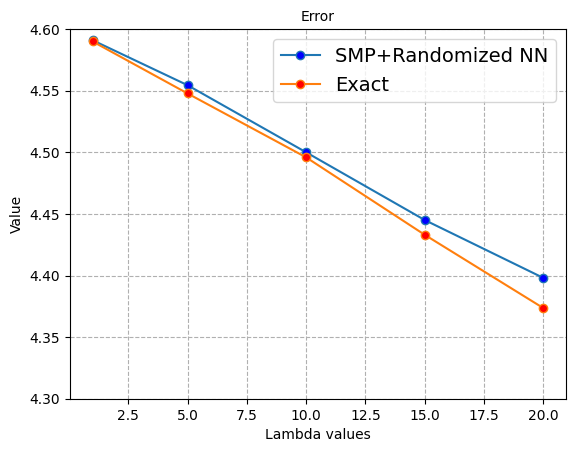

In [158]:
fig = plt.figure(facecolor=(1, 1, 1))
plt.grid(True,which="both", linestyle='--')

plt.plot(vec,pred,linestyle='-', marker='o',
     markerfacecolor='blue')
plt.plot(vec,exactVal,linestyle='-', marker='o',
     markerfacecolor='red')
plt.ylim(4.30,4.60)
plt.ylabel('Value')
plt.xlabel('Lambda values')
plt.title('Error', fontsize=10)

plt.legend(["SMP+Randomized NN", "Exact"],fontsize=14)

#plt.savefig("hjb.png",bbox_inches='tight')

In [109]:
for param in md.mList[0].layers[0].parameters():
    print(param)

Parameter containing:
tensor([[-0.0186,  0.0103, -0.0056,  ...,  0.0211,  0.0215,  0.0054],
        [-0.0238, -0.0253, -0.0404,  ..., -0.0031, -0.0171, -0.0309],
        [-0.0472, -0.0354,  0.0099,  ...,  0.0285,  0.0013, -0.0207],
        ...,
        [ 0.0097, -0.0116,  0.0572,  ...,  0.0006, -0.0181,  0.0041],
        [ 0.0189, -0.0117,  0.0124,  ..., -0.0206,  0.0056, -0.0596],
        [ 0.0132, -0.0729, -0.0248,  ...,  0.0082,  0.0564, -0.0568]])
Parameter containing:
tensor([-0.0043,  0.0219,  0.0106, -0.0637,  0.0221, -0.0487,  0.0107,  0.0181,
        -0.0145, -0.0015,  0.0233,  0.0576,  0.0750,  0.0040, -0.0600,  0.0463,
        -0.0370, -0.0105, -0.0302, -0.0107, -0.0089,  0.0098,  0.0040,  0.0140,
        -0.0225, -0.0050, -0.0296,  0.0234,  0.0034, -0.0263, -0.0102, -0.0415,
         0.0456,  0.0298,  0.0052, -0.0470,  0.0077, -0.0249,  0.0133, -0.0527,
        -0.0096, -0.0337, -0.0067, -0.0328, -0.0198, -0.0124, -0.0574,  0.0112,
        -0.0146, -0.0055,  0.0366, -0.0200